<a href="https://colab.research.google.com/github/HoangTimothy/DL-Assignment-DNAC1/blob/main/notebooks/DL_BTL1_Multimodal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.&nbsp; User manual

- This Google Colab file implements a deep learning pipeline for a multimodal (text + image) dataset (CUB-200-2011).

- To run this notebook, you just need to click the Colab `Run all` button (library installation and dataset loading are automated).

# 1.&nbsp; Prepare the necessary data and libraries

## 1.1.&nbsp; Verify and install necessary libraries

In [1]:
!pip install -q --upgrade torchao>=0.16.0

In [2]:
import os
import time
import copy
import random
import kagglehub
import wandb
import shutil
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import CLIPProcessor, CLIPModel
from transformers import AutoProcessor, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, PeftModel

import PIL.ImageFile
from PIL import Image

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True # Faster
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

In [3]:
from google.colab import userdata
os.environ["WANDB_API_KEY"] = userdata.get('WANDB_API_KEY')

## 1.2. Download Dataset

In [4]:
cub_root_dir = kagglehub.dataset_download("wenewone/cub2002011")
print("Path to dataset files:", cub_root_dir)

100%|██████████| 1.49G/1.49G [00:17<00:00, 89.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wenewone/cub2002011/versions/7


## 1.3. Custom Multimodal Dataset

In [5]:
class CUBMultimodalDataset(Dataset):
    def __init__(
        self,
        root_dir,
        class_splits,
        mode='train', # 'train', 'zero_shot', 'few_shot'
        subset='support', # 'support', 'query'
        processor=None,
        k_shots=None,
        seed=42,
        support_indices=None
    ):
        self.root_dir = root_dir
        self.mode = mode
        self.processor = processor
        self.k_shots = k_shots
        self.seed = seed

        random.seed(seed)

        # Paths
        image_root = os.path.join(root_dir, 'CUB_200_2011')
        self.image_dir = os.path.join(image_root, 'images')
        self.text_dir = os.path.join(root_dir, 'cvpr2016_cub', 'text_c10')

        # Load metadata
        images_txt = os.path.join(image_root, 'images.txt')
        labels_txt = os.path.join(image_root, 'image_class_labels.txt')
        images_df = pd.read_csv(images_txt, sep=' ', names=['img_id', 'filepath'])
        labels_df = pd.read_csv(labels_txt, sep=' ', names=['img_id', 'class_id'])
        df = images_df.merge(labels_df, on='img_id')

        # Class split
        self.train_classes = class_splits['train_classes']
        self.val_classes = class_splits['val_classes']
        self.test_classes = class_splits['test_classes']

        # Filter by mode
        if mode == 'train':
            self.active_classes = self.train_classes
        elif mode == 'val':
            self.active_classes = self.val_classes
        elif mode in ['zero_shot', 'few_shot']:
            self.active_classes = self.test_classes

        self.data = df[df['class_id'].isin(self.active_classes)].copy()

        # Local label mapping (0-based)
        self.label_map = {cls: i for i, cls in enumerate(sorted(self.active_classes))}

        # Support/Query Split for Few-Shot
        if mode == 'few_shot':
            if subset == 'support':
                self.data = self.data.loc[support_indices]
            else: # subset == 'query'
                self.data = self.data.drop(support_indices)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Image and text paths
        img_path = os.path.join(self.image_dir, row['filepath'])
        text_rel_path = row['filepath'].replace('.jpg', '.txt')
        text_path = os.path.join(self.text_dir, text_rel_path)

        # Load image and captions
        image = Image.open(img_path).convert('RGB')
        with open(text_path, 'r', encoding='utf-8') as f:
            captions = [c.strip() for c in f.readlines() if c.strip()]

        # Dynamic Text Sampling
        if self.mode == 'train':
            text = random.choice(captions)
        else:
            text = captions[0]  # deterministic for eval

        label = self.label_map[row['class_id']]

        # Processor
        if self.processor:
            encoding = self.processor(
                text=text,
                images=image,
                return_tensors="pt",
                padding="max_length",
                truncation=True,
                max_length=77
            )
            encoding = {k: v.squeeze(0) for k, v in encoding.items()}
            encoding['label'] = torch.tensor(label, dtype=torch.long)
            return encoding

        return image, text, label

## 1.4. Helper Functions

In [6]:
def get_cub_class_names(root_dir):
    """Đọc và làm sạch tên 200 loài chim từ tệp classes.txt"""
    classes_txt = os.path.join(root_dir, 'CUB_200_2011', 'classes.txt')
    # Cấu trúc tệp: "1 001.Black_footed_Albatross"
    classes_df = pd.read_csv(classes_txt, sep=' ', names=['class_id', 'class_name'])

    # Loại bỏ tiền tố số và thay dấu gạch dưới bằng khoảng trắng
    # Kết quả: "Black footed Albatross"
    clean_names = classes_df['class_name'].apply(lambda x: x.split('.')[1].replace('_', ' '))
    return clean_names.tolist()

In [7]:
def generate_support_indices(labels, k_shots, seed=42):
    """
    Hàm lấy chỉ mục cho Support Set từ nhãn dạng Tensor.
    """
    # Nếu đầu vào là PyTorch Tensor, chuyển sang Numpy
    if torch.is_tensor(labels):
        labels_np = labels.cpu().numpy()
    else:
        labels_np = labels

    # Tạo DataFrame tạm thời để thực hiện groupby.sample
    df_temp = pd.DataFrame({'class_id': labels_np})

    # Thực hiện lấy mẫu K-shot cho mỗi lớp
    # random_state đảm bảo tính tái lập (reproducibility)
    support_df = df_temp.groupby('class_id').sample(n=k_shots, random_state=seed)

    # Trả về list các index
    return support_df.index.tolist()

# 2.&nbsp; Exploratory Data Analysis (EDA)

## 2.1. Dataset Overview

In [8]:
# Define class splits (200 classes)
classes = np.arange(1, 201)
np.random.seed(seed)
np.random.shuffle(classes)
class_splits = {
    'train_classes': classes[:100].tolist(),   # 100 Base Classes
    'val_classes': classes[100:150].tolist(),  # 50 Val Classes
    'test_classes': classes[150:].tolist()     # 50 Novel Classes
}

In [9]:
image_root = os.path.join(cub_root_dir, 'CUB_200_2011')
images_df = pd.read_csv(os.path.join(image_root, 'images.txt'), sep=' ', names=['img_id', 'filepath'])
labels_df = pd.read_csv(os.path.join(image_root, 'image_class_labels.txt'), sep=' ', names=['img_id', 'class_id'])
df_full = images_df.merge(labels_df, on='img_id').sort_values('img_id').reset_index(drop=True)
print("Dataset Information:")
display(df_full.head())
df_full.info()

Dataset Information:


,img_id,filepath,class_id
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11788 entries, 0 to 11787
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   img_id    11788 non-null  int64 
 1   filepath  11788 non-null  object
 2   class_id  11788 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 276.4+ KB


## 2.2. Class Distribution

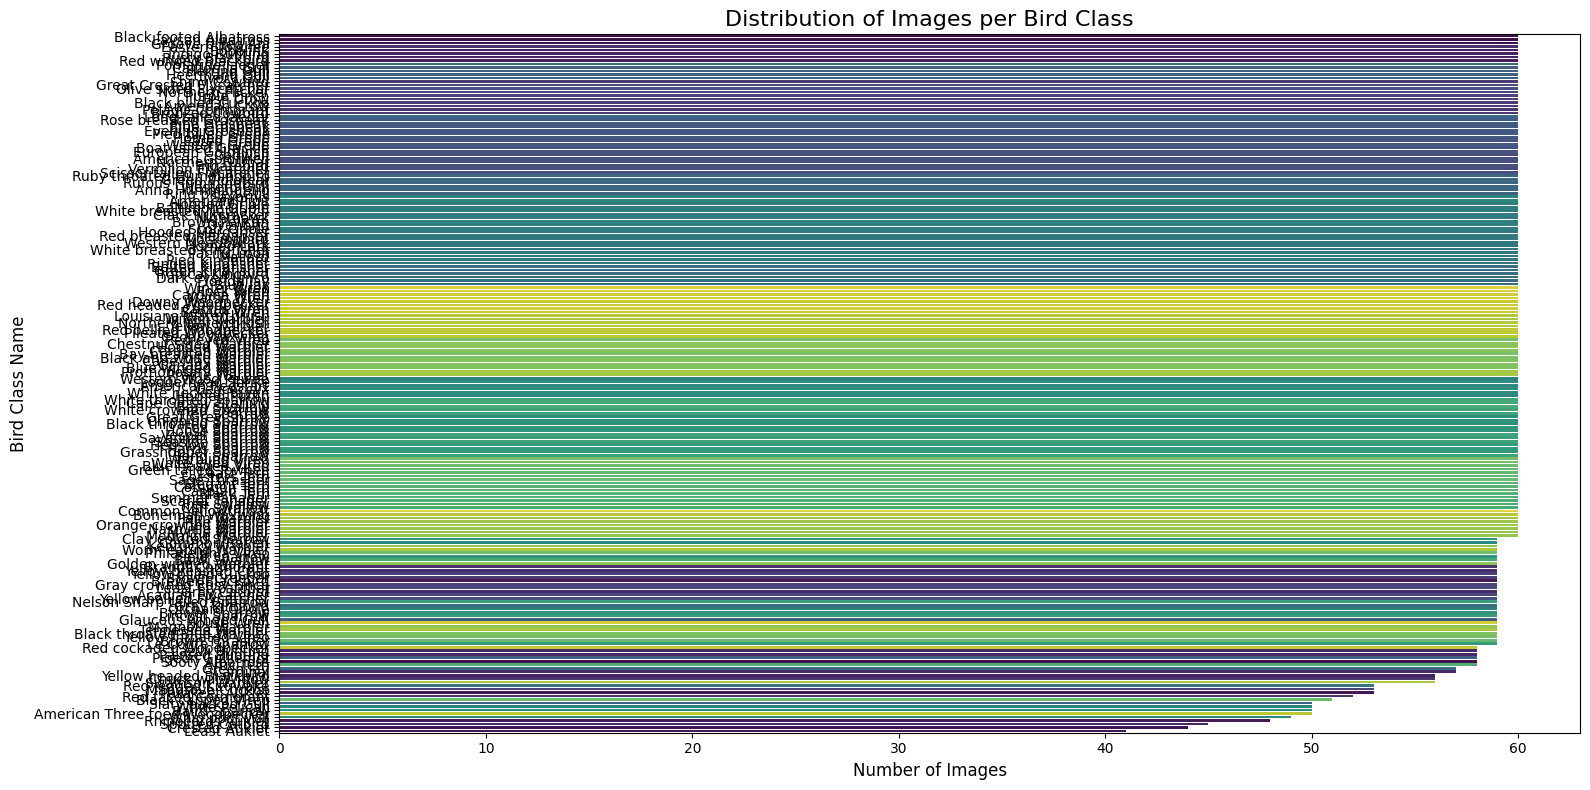

Total unique classes: 200
Minimum images per class: 41
Maximum images per class: 60


In [10]:
bird_class_names = get_cub_class_names(cub_root_dir)
class_names_map = {i + 1: name for i, name in enumerate(bird_class_names)}

df_full['class_name'] = df_full['class_id'].map(class_names_map)

plt.figure(figsize=(16, 8))
sns.countplot(y='class_name', data=df_full, order=df_full['class_name'].value_counts().index, palette='viridis', hue='class_name', legend=False)
plt.title('Distribution of Images per Bird Class', fontsize=16)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Bird Class Name', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Total unique classes: {df_full['class_id'].nunique()}")
print(f"Minimum images per class: {df_full['class_id'].value_counts().min()}")
print(f"Maximum images per class: {df_full['class_id'].value_counts().max()}")

## 2.3. Sample Images and Captions

--- Sample Images with Captions ---


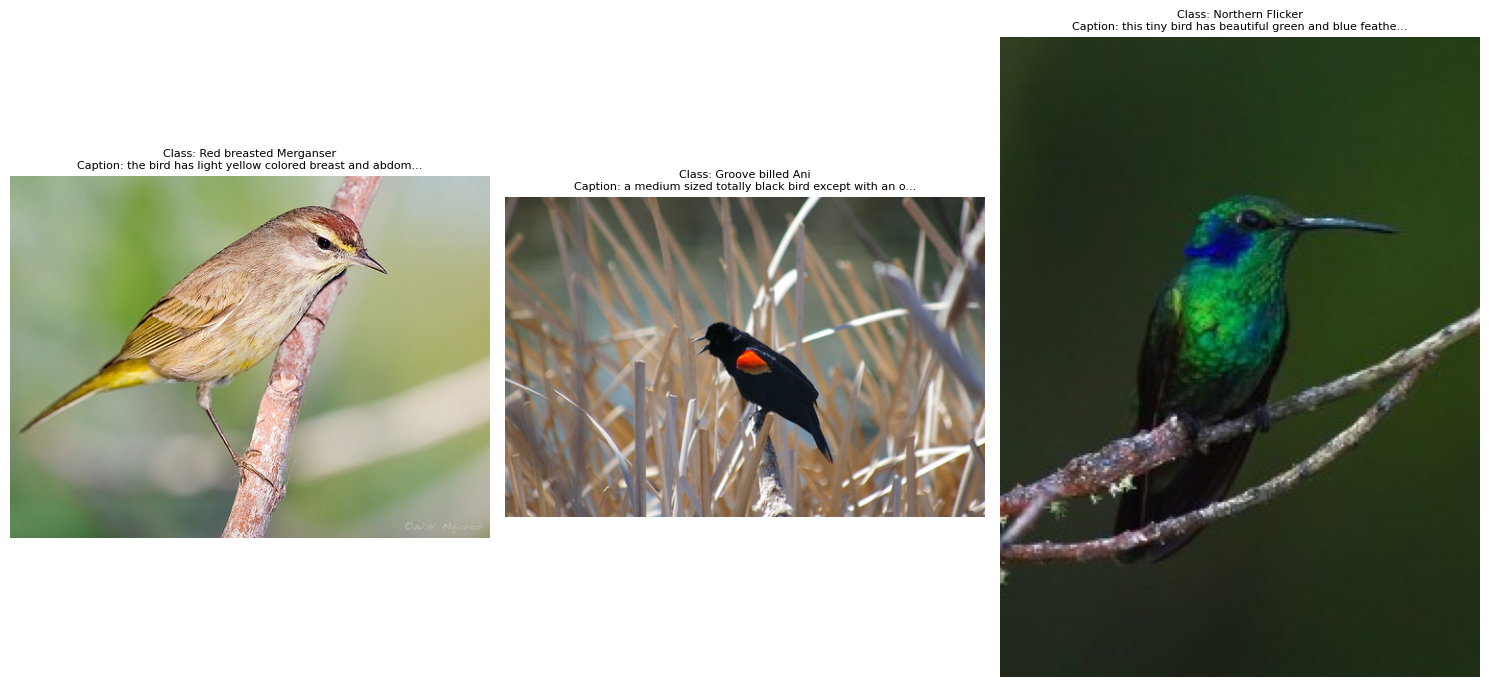

In [11]:
print('--- Sample Images with Captions ---')
sample_dataset = CUBMultimodalDataset(
    root_dir=cub_root_dir,
    class_splits=class_splits,
    mode='train',
    processor=None
)

num_samples = 3
plt.figure(figsize=(15, 10))
for i in range(num_samples):
    # Randomly select an index
    idx = random.randint(0, len(sample_dataset) - 1)
    image, text, label = sample_dataset[idx]
    class_name = class_names_map[df_full['class_id'].iloc[idx]]

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(image)
    plt.title(f"Class: {class_name}\nCaption: {text[:50]}...", fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

# 3.&nbsp; LoRA Domain Adaptation

In [21]:
# 1. Configuration
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "openai/clip-vit-base-patch32" # Recommended ViT-B/16
batch_size = 32
lr = 5e-5
epochs = 10
r = 8  # Rank for LoRA

# 2. Initialize Model and Processor
processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id)

# 3. Apply LoRA Configuration
# We target the attention layers (q_proj, v_proj) in both Vision and Text towers
config = LoraConfig(
    r=r,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"], # Standard targets for ViT/Transformers
    lora_dropout=0.1,
    bias="none",
    modules_to_save=[],
)

model = get_peft_model(model, config)
model.print_trainable_parameters() # Should show ~1% or less parameters
model.to(device)

# 4. Prepare Dataset (100 Base Classes)
# Assuming class_splits['train_classes'] contains your 100 base class IDs
train_dataset = CUBMultimodalDataset(
    root_dir=cub_root_dir,
    class_splits=class_splits,
    mode='train',
    processor=processor,
    seed=seed
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    persistent_workers=True
)

# 5. Optimizer & Loss
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

# CLIP Training traditionally uses Symmetric Contrastive Loss
def contrastive_loss(logits_per_image, logits_per_text):
    labels = torch.arange(len(logits_per_image), device=device)
    loss_i = nn.functional.cross_entropy(logits_per_image, labels)
    loss_t = nn.functional.cross_entropy(logits_per_text, labels)
    return (loss_i + loss_t) / 2

# 6. Training Loop
model.train()
for epoch in range(epochs):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    epoch_loss = 0

    for batch in pbar:
        optimizer.zero_grad(set_to_none=True)

        # Move inputs to GPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        pixel_values = batch['pixel_values'].to(device)

        # Forward Pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            return_loss=False # We handle loss manually for clarity
        )

        # Calculate Symmetric Contrastive Loss
        loss = contrastive_loss(outputs.logits_per_image, outputs.logits_per_text)

        # Backward Pass
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    print(f"Epoch {epoch+1} Average Loss: {epoch_loss / len(train_loader):.4f}")

# 7. Save the Adapted LoRA weights
# This saves ONLY the small LoRA adapters, not the whole CLIP model (very small file)
model.save_pretrained("./clip-cub-lora-adapter")
print("LoRA Adaptation Complete!")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 983,040 || all params: 152,260,353 || trainable%: 0.6456


Epoch 1:   0%|          | 0/185 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a8844063600>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7a8844063600>^^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self._parent_pid == os.getpid(), 'can only test a child process'if w.is_alive():

               ^ ^  ^^^^^^^^^^^^^^^^^^^^^^


...

Epoch 2 Average Training Loss: 0.3835


Extracting Features:   0%|          | 0/93 [00:00<?, ?it/s]

Epoch 2 Zero-Shot Val Top-1 Accuracy: 0.6577


Epoch 3:   0%|          | 0/185 [00:00<?, ?it/s]

KeyboardInterrupt: 

# 4.&nbsp; Feature Extraction

In [13]:
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extracting Features"):
            images = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            # Get visual embeddings
            vision_outputs = model.vision_model(images)
            image_features = vision_outputs[1]
            image_features = model.visual_projection(image_features)
            # Normalize for cosine similarity
            image_features /= image_features.norm(dim=-1, keepdim=True)

            all_features.append(image_features.cpu())
            all_labels.append(labels.cpu())

    return torch.cat(all_features), torch.cat(all_labels)

def get_text_features(model, class_names, processor, device):
    """
    Generates text features by averaging multiple prompt templates.
    This significantly improves zero-shot robustness on fine-grained datasets.
    """
    model.eval()

    # Standard bird-specific templates
    templates = [
        "a photo of a {}, a type of bird.",
        "a cropped photo of a {}, a bird.",
        "a close-up photo of a {}, a bird.",
        "a photo of the {}, a bird.",
        "this is a photo of a {}, a type of bird."
    ]

    all_class_features = []

    with torch.no_grad():
        for name in class_names:
            class_embeddings = []
            for template in templates:
                prompt = template.format(name)
                inputs = processor(text=[prompt], padding=True, return_tensors="pt").to(device)

                text_outputs = model.text_model(**inputs)
                text_feature = text_outputs[1] # Lấy pooler_output
                text_feature = model.text_projection(text_feature)
                text_feature /= text_feature.norm(dim=-1, keepdim=True) # Chuẩn hóa từng câu lệnh
                class_embeddings.append(text_feature)

            # Stack the 5 templates for this class and average them
            class_embeddings = torch.cat(class_embeddings, dim=0)
            ensembled_feature = class_embeddings.mean(dim=0, keepdim=True)

            # Normalize the ensembled vector
            ensembled_feature /= ensembled_feature.norm(dim=-1, keepdim=True)
            all_class_features.append(ensembled_feature)

    return torch.cat(all_class_features).cpu()

# 5.&nbsp; Zero-Shot and Few-Shot Evaluation

In [14]:
def calculate_metrics(logits, true_labels):
    """
    Calculates Top-1, Top-5, and F1 Macro given logits and true labels.
    """
    # Top-1
    preds = logits.argmax(dim=-1)
    top1_acc = (preds == true_labels).float().mean().item()

    # Top-5
    # Get the indices of the top 5 predictions for each sample
    _, top5_preds = logits.topk(k=5, dim=-1)
    # Check if the true label is in those top 5 indices
    top5_acc = (top5_preds == true_labels.unsqueeze(-1)).any(dim=-1).float().mean().item()

    # F1 Macro (using sklearn for simplicity)
    f1_mac = f1_score(true_labels.numpy(), preds.numpy(), average='macro')

    return {"top1": top1_acc, "top5": top5_acc, "f1_macro": f1_mac}

def run_zero_shot(query_feat, text_feat, query_labels):
    # Logit scale isn't strictly needed for pure ZS metrics, but standard for completeness
    logits = 100.0 * (query_feat @ text_feat.t())
    return calculate_metrics(logits, query_labels)

def run_linear_probe(support_feat, support_labels, query_feat, query_labels):
    classifier = LogisticRegression(max_iter=1000, C=1.0)
    classifier.fit(support_feat.numpy(), support_labels.numpy())

    # Use decision_function to get raw logits for Top-5 calculation
    logits = torch.tensor(classifier.decision_function(query_feat.numpy()))

    # In binary classification, decision_function returns 1D array.
    # Since CUB is 50-way, it returns shape (N, 50).
    return calculate_metrics(logits, query_labels)

def run_tip_adapter(support_feat, support_labels, query_feat, query_labels, text_feat, alpha=1.0, beta=5.0):
    # 1. Zero-shot branch (MUST scale by 100.0 here so it balances with the cache)
    zero_shot_logits = 100.0 * (query_feat @ text_feat.t())

    # 2. Cache branch
    num_classes = text_feat.shape[0]
    cache_values = torch.nn.functional.one_hot(support_labels, num_classes).float()

    affinity = torch.exp(-beta * (1 - query_feat @ support_feat.t()))
    cache_logits = affinity @ cache_values

    # 3. Combine
    final_logits = alpha * cache_logits + zero_shot_logits

    return calculate_metrics(final_logits, query_labels)

# 6.&nbsp; Run Full Experiment

In [16]:
def run_full_experiment(model, test_loader, class_names, processor, device, label_tag):
    """
    Runs the full suite (Zero-Shot, Linear Probe, Tip-Adapter) for a specific model.
    """
    print(f"\n>>> Starting Evaluation for: {label_tag}")

    # 1. Cache Text and Image Features
    text_features = get_text_features(model, class_names, processor, device)
    img_features, img_labels = extract_features(model, test_loader, device)

    results = []
    shots = [1, 2, 4, 8, 16]

    for k in shots:
        print(f"Running {k}-shot...")
        # Reproducible support sampling
        support_idx = generate_support_indices(img_labels, k_shots=k, seed=seed)
        query_idx = [i for i in range(len(img_labels)) if i not in support_idx]

        s_feat, s_labels = img_features[support_idx], img_labels[support_idx]
        q_feat, q_labels = img_features[query_idx], img_labels[query_idx]

        # A. Zero-Shot (Run on Query Set for fair comparison)
        zs = run_zero_shot(q_feat, text_features, q_labels)

        # B. Linear Probe
        lp = run_linear_probe(s_feat, s_labels, q_feat, q_labels)

        # C. Tip-Adapter
        tip = run_tip_adapter(s_feat, s_labels, q_feat, q_labels, text_features)

        results.append({
            "k": k,
            "zs": zs,
            "lp": lp,
            "tip": tip
        })

    return pd.DataFrame(results)

# 7.&nbsp; Main Execution

In [19]:
model_id = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_id, use_fast=False)

# 1. Load Data for 50 Test Classes
test_dataset = CUBMultimodalDataset(
    root_dir=cub_root_dir,
    class_splits=class_splits,
    mode='zero_shot', # This filters to our 50 test classes
    processor=processor
)
test_loader = DataLoader(test_dataset, batch_size=32, num_workers=2, persistent_workers=True)
test_class_names = [class_names_map[i] for i in sorted(class_splits['test_classes'])]

# --- PART A: Vanilla CLIP ---
base_model = CLIPModel.from_pretrained(model_id).to(device)
vanilla_results = run_full_experiment(base_model, test_loader, test_class_names, processor, device, "Vanilla CLIP")

# --- PART B: Adapted CLIP (LoRA) ---
# Load and Merge
lora_model = PeftModel.from_pretrained(base_model, "./clip-cub-lora-adapter")
merged_model = lora_model.merge_and_unload()
merged_model.to(device)
adapted_results = run_full_experiment(merged_model, test_loader, test_class_names, processor, device, "Adapted CLIP")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



>>> Starting Evaluation for: Vanilla CLIP


Extracting Features:   0%|          | 0/93 [00:00<?, ?it/s]

Running 1-shot...
Running 2-shot...
Running 4-shot...
Running 8-shot...
Running 16-shot...

>>> Starting Evaluation for: Adapted CLIP


Extracting Features:   0%|          | 0/93 [00:00<?, ?it/s]

Running 1-shot...
Running 2-shot...
Running 4-shot...
Running 8-shot...
Running 16-shot...


# 8.&nbsp; Visualization

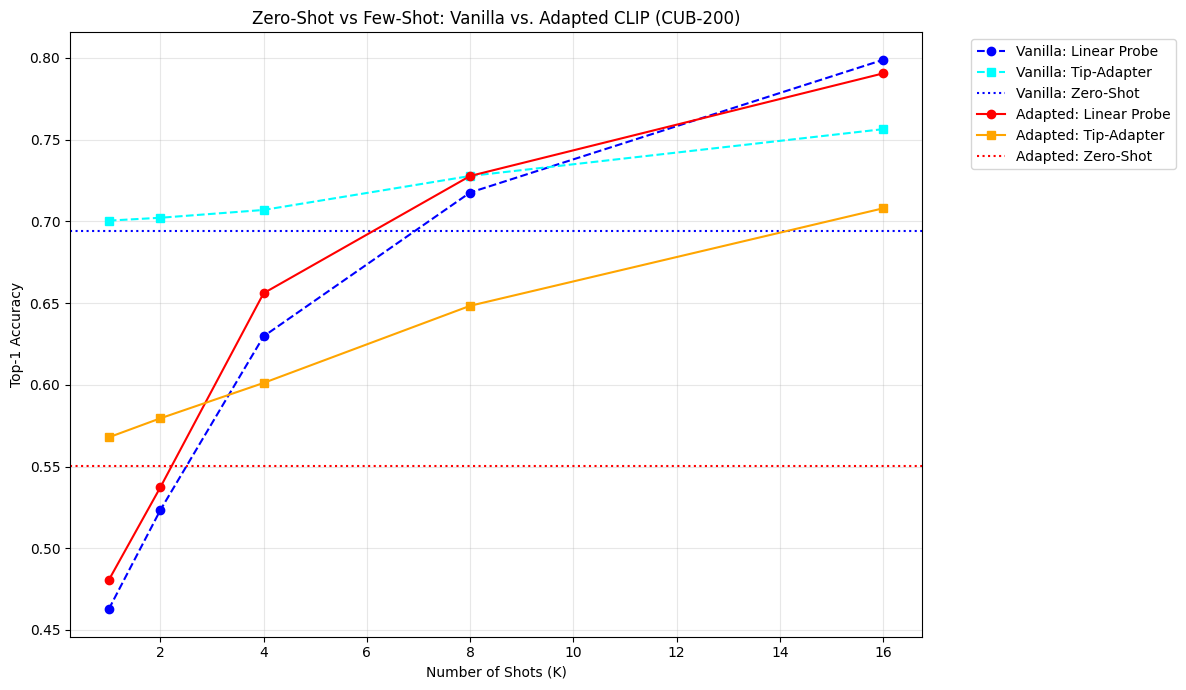


--- FINAL COMPARISON (All Metrics) ---
 K Vanilla ZS Top-1 Vanilla ZS Top-5 Vanilla ZS F1 Macro Adapted ZS Top-1 Adapted ZS Top-5 Adapted ZS F1 Macro Vanilla LP Top-1 Vanilla LP Top-5 Vanilla LP F1 Macro Adapted LP Top-1 Adapted LP Top-5 Adapted LP F1 Macro Vanilla Tip Top-1 Vanilla Tip Top-5 Vanilla Tip F1 Macro Adapted Tip Top-1 Adapted Tip Top-5 Adapted Tip F1 Macro
 1           0.6943           0.9596              0.6769           0.5504           0.8944              0.5201           0.4626           0.8307              0.4450           0.4805           0.8441              0.4536            0.7005            0.9613               0.6833            0.5679            0.9034               0.5375
 2           0.6942           0.9599              0.6766           0.5488           0.8954              0.5183           0.5234           0.8937              0.5052           0.5373           0.8923              0.5127            0.7022            0.9634               0.6843            0.5795 

In [23]:
plt.figure(figsize=(12, 7))

# Plot Vanilla
plt.plot(vanilla_results['k'], vanilla_results['lp'].apply(lambda x: x['top1']), 'o--', color='blue', label='Vanilla: Linear Probe')
plt.plot(vanilla_results['k'], vanilla_results['tip'].apply(lambda x: x['top1']), 's--', color='cyan', label='Vanilla: Tip-Adapter')
plt.axhline(y=vanilla_results['zs'].apply(lambda x: x['top1']).iloc[0], color='blue', linestyle=':', label='Vanilla: Zero-Shot')

# Plot Adapted
plt.plot(adapted_results['k'], adapted_results['lp'].apply(lambda x: x['top1']), 'o-', color='red', label='Adapted: Linear Probe')
plt.plot(adapted_results['k'], adapted_results['tip'].apply(lambda x: x['top1']), 's-', color='orange', label='Adapted: Tip-Adapter')
plt.axhline(y=adapted_results['zs'].apply(lambda x: x['top1']).iloc[0], color='red', linestyle=':', label='Adapted: Zero-Shot')

plt.title("Zero-Shot vs Few-Shot: Vanilla vs. Adapted CLIP (CUB-200)")
plt.xlabel("Number of Shots (K)")
plt.ylabel("Top-1 Accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("experiment_results.png")
plt.show()

# Print a nice summary table with Top-1, Top-5, and F1 Macro
print("\n--- FINAL COMPARISON (All Metrics) ---")
summary_data = []
for i, k_shot in enumerate(vanilla_results['k']):
    summary_data.append({
        "K": k_shot,
        "Vanilla ZS Top-1": vanilla_results['zs'].iloc[i]['top1'],
        "Vanilla ZS Top-5": vanilla_results['zs'].iloc[i]['top5'],
        "Vanilla ZS F1 Macro": vanilla_results['zs'].iloc[i]['f1_macro'],
        "Adapted ZS Top-1": adapted_results['zs'].iloc[i]['top1'],
        "Adapted ZS Top-5": adapted_results['zs'].iloc[i]['top5'],
        "Adapted ZS F1 Macro": adapted_results['zs'].iloc[i]['f1_macro'],
        "Vanilla LP Top-1": vanilla_results['lp'].iloc[i]['top1'],
        "Vanilla LP Top-5": vanilla_results['lp'].iloc[i]['top5'],
        "Vanilla LP F1 Macro": vanilla_results['lp'].iloc[i]['f1_macro'],
        "Adapted LP Top-1": adapted_results['lp'].iloc[i]['top1'],
        "Adapted LP Top-5": adapted_results['lp'].iloc[i]['top5'],
        "Adapted LP F1 Macro": adapted_results['lp'].iloc[i]['f1_macro'],
        "Vanilla Tip Top-1": vanilla_results['tip'].iloc[i]['top1'],
        "Vanilla Tip Top-5": vanilla_results['tip'].iloc[i]['top5'],
        "Vanilla Tip F1 Macro": vanilla_results['tip'].iloc[i]['f1_macro'],
        "Adapted Tip Top-1": adapted_results['tip'].iloc[i]['top1'],
        "Adapted Tip Top-5": adapted_results['tip'].iloc[i]['top5'],
        "Adapted Tip F1 Macro": adapted_results['tip'].iloc[i]['f1_macro']
    })

full_summary_df = pd.DataFrame(summary_data)
# Format to 4 decimal places for better readability
for col in full_summary_df.columns:
    if col != 'K':
        full_summary_df[col] = full_summary_df[col].apply(lambda x: f'{x:.4f}')

print(full_summary_df.to_string(index=False))

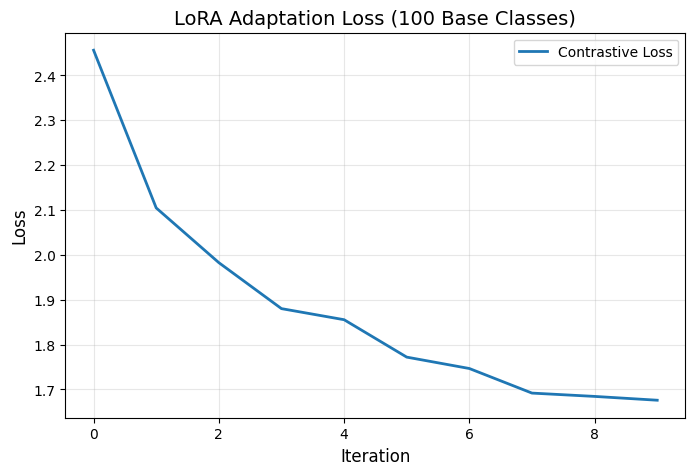

In [22]:
def plot_training_loss(loss_history):
    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, color='#1f77b4', linewidth=2, label='Contrastive Loss')
    plt.title("LoRA Adaptation Loss (100 Base Classes)", fontsize=14)
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

loss_values = [
    2.4563,
    2.1047,
    1.9827,
    1.8802,
    1.8555,
    1.7721,
    1.7467,
    1.6919,
    1.6845,
    1.6760
]

plot_training_loss(loss_values)